In [1]:
import pandas as pd
import numpy as np
wbcd=pd.read_csv("wbcd.csv")
wbcd.head()
#there 569 rows and 12 columns

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,868871,B,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,9012568,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766


In [5]:
wbcd.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
#IN output column there is only b for bebnign ad M for Malignant
#let us first convert it to benign and malignant
wbcd['diagnosis']=np.where(wbcd['diagnosis']=='B','Beniegn',wbcd['diagnosis'])
#IN wbcd there is column named diagnosis ,where ever there is 'B' replace with 'Beniegn'

#similarly where ever there is M in the same column replace it with malignant
wbcd['diagnosis']=np.where(wbcd['diagnosis']=='M','Malignant',wbcd['diagnosis'])

In [11]:
#0th column is patient id let us drop it
wbcd=wbcd.iloc[:,1:32]


In [17]:
#NOrmalization
def norm_func(i):
    x=(i-i.min())/(i.max()-i.min())
    return x

#now let us apply this funtion to the datframe
wbcd_n=norm_func(wbcd.iloc[:,1:32])

In [19]:
#Let us now apply x as input and y asoutput
X=np.array(wbcd_n.iloc[:,:])
##Since is wbcd norm we are alredy excluding output column ,hence all rows and 
y=np.array(wbcd['diagnosis'])


In [23]:
#NOw let us split the data into training and testing 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [35]:
#There you are passing X,y insted dataframe handles
#there could be chances of unbalancing the data
#let us assumne you have 100 datapoints ,out of which 80NC , 20 cancer
#There data points must be equally distributed 
#there is statified sampling concept is used
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=21)
knn.fit(X_train,y_train)
pred=knn.predict(X_test)
pred

array(['Malignant', 'Beniegn', 'Beniegn', 'Malignant', 'Beniegn',
       'Malignant', 'Beniegn', 'Malignant', 'Beniegn', 'Beniegn',
       'Beniegn', 'Malignant', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn',
       'Beniegn', 'Beniegn', 'Malignant', 'Malignant', 'Malignant',
       'Beniegn', 'Malignant', 'Malignant', 'Beniegn', 'Malignant',
       'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn',
       'Malignant', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn',
       'Malignant', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn',
       'Malignant', 'Beniegn', 'Malignant', 'Beniegn', 'Beniegn',
       'Malignant', 'Malignant', 'Beniegn', 'Beniegn', 'Beniegn',
       'Malignant', 'Beniegn', 'Malignant', 'Malignant', 'Malignant',
       'Beniegn', 'Malignant', 'Beniegn', 'Malignant', 'Malignant',
       'Malignant', 'Malignant', 'Beniegn', 'Malignant', 'Beniegn',
       'Beniegn', 'Malignant', 'Beniegn', 'Beniegn', 'Beniegn', 'Beniegn',
       'Beniegn', 'Ma

In [39]:
#Now let us evaluate the model
from sklearn.metrics import accuracy_score
print(accuracy_score(pred,y_test)) 
pd.crosstab(pred,y_test)
#Let us us check the applicablity of the model
#i.e missclassification actual patient is malignanat 
#i.e it is cancer patient but the predicted is benign is 1
##Actual patient is benign and predicted as cancer patient is 5
#Hence this model is not acceptable


0.9736842105263158


col_0,Beniegn,Malignant
row_0,,
Beniegn,67,2
Malignant,1,44


In [41]:
#let us try to select correct value of k
acc=[]
#Running KNN algorithm for k=3 to 50 in steps of 2
for i in range(3,50,2):
    neigh=KNeighborsClassifier(n_neighbors=i)
    neigh.fit(X_train,y_train)
    pred=neigh.predict(X_test)
    train_acc=np.mean(neigh.predict(X_train)==y_train)
    test_acc=np.mean(neigh.predict(X_test)==y_test)
    acc.append([train_acc,test_acc])

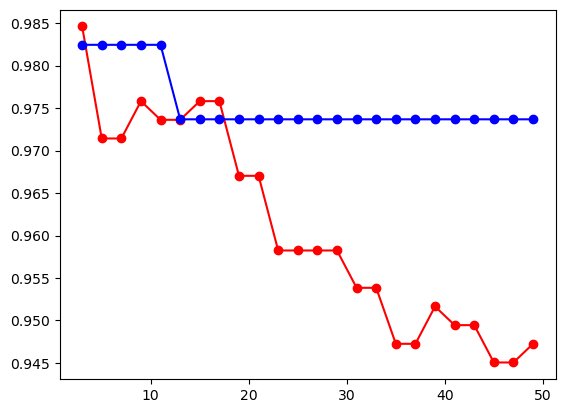

In [49]:
#If you will see the acc ,it has got two accuracy ,i[0]-train_acc
#i[1]=tets_acc
#to plot the graph of train_acc and test_acc
import matplotlib.pyplot as plt
plt.plot(np.arange(3,50,2),[i[0] for i in acc],"ro-")
plt.plot(np.arange(3,50,2),[i[1] for i in acc],"bo-")


In [51]:
#there are 3,5,7 and 9 are possible values where accuracy is good
#let us check for k=3
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)
pred=knn.predict(X_test)
print(accuracy_score(y_test,pred))
pd.crosstab(y_test,pred)

0.9824561403508771


col_0,Beniegn,Malignant
row_0,,
Beniegn,68,0
Malignant,2,44


In [ ]:
#i.e missclassification , actual patient is malignant